<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/Outliers%26PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('EmployeeAttrition.csv')

In [ ]:
df.shape

(1470, 35)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df.columns[df.nunique()==1]

Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='object')

In [ ]:
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours','EmployeeNumber'],inplace=True)
df.shape

(1470, 31)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(1470, 31)

In [ ]:
df.isnull().sum().sum() ## total nulls in data is 0

np.int64(0)

X & Y


In [ ]:
X = df.drop(columns=['Attrition'])
Y = df['Attrition']
X.shape,Y.shape

((1470, 30), (1470,))

In [ ]:
X.dtypes

,0
Age,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object
HourlyRate,int64


In [ ]:
# label Encoding --> Business
label_map = {'BusinessTravel':{'Travel_Rarely':1,'Travel_Frequently':2,'Non-Travel':0}}
X.replace(label_map,inplace=True)
X['BusinessTravel'].unique()


/tmp/ipykernel_29553/2921731912.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.replace(label_map,inplace=True)


array([1, 2, 0])

In [ ]:
X_ohe = pd.get_dummies(X)
X_ohe.shape

(1470, 49)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test  = train_test_split(X_ohe,Y,test_size=0.3,random_state=7,stratify=Y)

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((1029, 49), (441, 49), (1029,), (441,))

In [ ]:
# Separating out categorical columns

cat_col = X_train.columns[X_train.nunique() < 15]
cat_col

Index(['BusinessTravel', 'Education', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TrainingTimesLastYear', 'WorkLifeBalance',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single', 'OverTime_No

In [ ]:
# Separating out continous columns

con_col = X_train.columns[X_train.nunique() > 15]
con_col

Index(['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
       'MonthlyRate', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

# Outlier Detection
-Zscore
-IQR

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train) # fit=> finds the values required for the formula (here finds mean and std for standard scaler formula )
X_train_sc = sc.transform(X_train) # applies the formula using values found and stored in the fit process in train data
X_test_sc = sc.transform(X_test)

X_train_sc.shape

(1029, 49)

What does fit and transform do? When to use what?
--
use fit and transform / fit_transform when pre-processing/Feature Selection
-
use fit and predict / fit_predict for ML Algo/Predictions   

In [ ]:
def outlier_detection_zc(df,col):
  print("Outliers in column->",col)
  o_count = df.loc[(df[col] < -3) |(df[col]>3),col].shape[0]
  print(o_count)

detect outliers based on Z-score

In [ ]:
X_train_sc = pd.DataFrame(X_train_sc,columns=X_train.columns)

for col in con_col:
  outlier_detection_zc(X_train_sc,col)

Outliers in column-> Age
0
Outliers in column-> DailyRate
0
Outliers in column-> DistanceFromHome
0
Outliers in column-> HourlyRate
0
Outliers in column-> MonthlyIncome
0
Outliers in column-> MonthlyRate
0
Outliers in column-> TotalWorkingYears
14
Outliers in column-> YearsAtCompany
19
Outliers in column-> YearsInCurrentRole
11
Outliers in column-> YearsSinceLastPromotion
26
Outliers in column-> YearsWithCurrManager
8


In [ ]:
# Outlier detection using IQR

In [ ]:
def outlier_detection_iqr(df,col):
  q1,q3 = df[col].quantile([0.25,0.75])
  iqr = q3-q1
  lb = q1 - 1.5 * iqr
  ub = q3 + 1.5 * iqr
  print("Outliers in column->",col)
  o_count = df.loc[(df[col]<lb)|(df[col]>ub),col].shape[0]
  print(o_count)

In [ ]:
## more outlier detected -- since iqr based more stable , since we dont use mean / median in calculation
for col in con_col:
  outlier_detection_iqr(X_train,col)

Outliers in column-> Age
0
Outliers in column-> DailyRate
0
Outliers in column-> DistanceFromHome
0
Outliers in column-> HourlyRate
0
Outliers in column-> MonthlyIncome
69
Outliers in column-> MonthlyRate
0
Outliers in column-> TotalWorkingYears
45
Outliers in column-> YearsAtCompany
69
Outliers in column-> YearsInCurrentRole
11
Outliers in column-> YearsSinceLastPromotion
73
Outliers in column-> YearsWithCurrManager
8


In [ ]:
# Outlier removal using z-score

def outlier_removal_zc(df,col):
  df1 = df.copy()
  print("Column->",col)
  print("Rows before removing outliers",df1.shape[0])
  df1 = df1.loc[(df1[col] >= -3) & (df1[col] <= 3),:]
  print("Rows after removing outliers",df1.shape[0])
  return df1

In [ ]:
X_train_sc_or = X_train_sc.copy()
for col in con_col:
  X_train_sc_or = outlier_removal_zc(X_train_sc_or,col)

Column-> Age
Rows before removing outliers 1029
Rows after removing outliers 1029
Column-> DailyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column-> DistanceFromHome
Rows before removing outliers 1029
Rows after removing outliers 1029
Column-> HourlyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column-> MonthlyIncome
Rows before removing outliers 1029
Rows after removing outliers 1029
Column-> MonthlyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column-> TotalWorkingYears
Rows before removing outliers 1029
Rows after removing outliers 1015
Column-> YearsAtCompany
Rows before removing outliers 1015
Rows after removing outliers 1000
Column-> YearsInCurrentRole
Rows before removing outliers 1000
Rows after removing outliers 992
Column-> YearsSinceLastPromotion
Rows before removing outliers 992
Rows after removing outliers 976
Column-> YearsWithCurrManager
Rows before removing outliers 976
Rows after remo

In [ ]:
# IQR based removal

def outlier_removal_iqr(df,col):
  df1 = df.copy()
  q1,q3 = df[col].quantile([0.25,0.75])
  iqr = q3-q1
  lb = q1 - 1.5 * iqr
  ub = q3 + 1.5 * iqr
  print("Column->",col)
  print("Rows before removing outliers",df1.shape[0])
  df1 = df1.loc[(df1[col]>=lb)&(df1[col]<=ub),:]
  print("Rows after removing outliers",df1.shape[0])
  return df1


In [ ]:
X_train_iqr = X_train.copy()
for col in con_col:
  X_train_iqr = outlier_removal_iqr(X_train_iqr,col)

'X_train_iqr = X_train.copy()\nfor col in con_col:\n  X_train_iqr = outlier_removal_iqr(X_train_iqr,col)'

Never run iqr based outlier removal multiple times-- once outlier cleaned and you recheck detect outliers, now the calculations will differ because the after removal of records values changed, and hence the upper bound and lower bound will shift and you will still see more outliers.

Outlier Imputations --
replace outliers with min and max values   

In [ ]:
def outlier_impute_zc(df,col):
  df1 =  df.copy()
  print("Column-->",col)
  df1.loc[(df1[col]<-3),col] = -3
  df1.loc[(df1[col]>3),col] = 3
  print(df1[col].min(),df1[col].max())
  return df1

In [ ]:
X_train_sc_io = X_train_sc.copy()
for col in con_col:
  X_train_sc_io = outlier_impute_zc(X_train_sc_io,col)

Column--> Age
-2.0460451710081347 2.529447957452466
Column--> DailyRate
-1.7174708636889437 1.7349192671167921
Column--> DistanceFromHome
-0.997432893693513 2.5308711619353996
Column--> HourlyRate
-1.778655035046836 1.6591457585352494
Column--> MonthlyIncome
-1.1619324653374639 2.9272683827988875
Column--> MonthlyRate
-1.7231722576056423 1.771638064367085
Column--> TotalWorkingYears
-1.4235994340147937 3.0
Column--> YearsAtCompany
-1.1539443619793066 3.0
Column--> YearsInCurrentRole
-1.195567661761814 3.0
Column--> YearsSinceLastPromotion
-0.676713965401559 3.0
Column--> YearsWithCurrManager
-1.1714142612068223 3.0


In [ ]:
def outlier_impute_iqr(df,col):
  df1 =  df.copy()
  q1,q3 = df1[col].quantile([0.25,0.75])
  iqr = q3-q1
  lb = q1 - 1.5 * iqr
  ub = q3 + 1.5 * iqr
  print("Column-->",col)
  df1.loc[(df1[col]<lb),col] = lb
  df1.loc[(df1[col]>ub),col] = ub
  print(lb,ub,df1[col].min(),df1[col].max())
  return df1

In [ ]:
X_train_io = X_train.copy() ## DIFF IN  OUTPUT CU INPUT DATA NOT SCALED ELSE-- IT IS CORRECT

for col in con_col:
  X_train_io = outlier_impute_iqr(X_train_io,col)

Column--> Age
10.5 62.5 18.0 60.0
Column--> DailyRate
-583.0 2209.0 103 1499
Column--> DistanceFromHome
-14.5 29.5 1.0 29.0
Column--> HourlyRate
-6.0 138.0 30 100
Column--> MonthlyIncome
-5542.5 16733.5 1009.0 16733.5
Column--> MonthlyRate
-10097.5 38730.5 2094.0 26999.0
Column--> TotalWorkingYears
-7.5 28.5 0.0 28.5
Column--> YearsAtCompany
-6.0 18.0 0 18
Column--> YearsInCurrentRole
-5.5 14.5 0.0 14.5
Column--> YearsSinceLastPromotion
-4.5 7.5 0.0 7.5
Column--> YearsWithCurrManager
-5.5 14.5 0.0 14.5


/tmp/ipykernel_29553/1102699481.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1.loc[(df1[col]<lb),col] = lb
/tmp/ipykernel_29553/1102699481.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-14.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1.loc[(df1[col]<lb),col] = lb
/tmp/ipykernel_29553/1102699481.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-5542.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1.loc[(df1[col]<lb),col] = lb
/tmp/ipykernel_29553/1102699481.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will 

APPLY PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
X_train.mean() # using raw data w/o scaler

,0
Age,36.781341
BusinessTravel,1.102041
DailyRate,797.472303
DistanceFromHome,8.915452
Education,2.921283
EnvironmentSatisfaction,2.728863
HourlyRate,66.216715
JobInvolvement,2.719145
JobLevel,2.040816
JobSatisfaction,2.719145


In [ ]:
## pass the training data without Standard Scaler
pca = PCA(random_state=7) # generate all possible components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca.shape,X_test_pca.shape

((1029, 49), (441, 49))

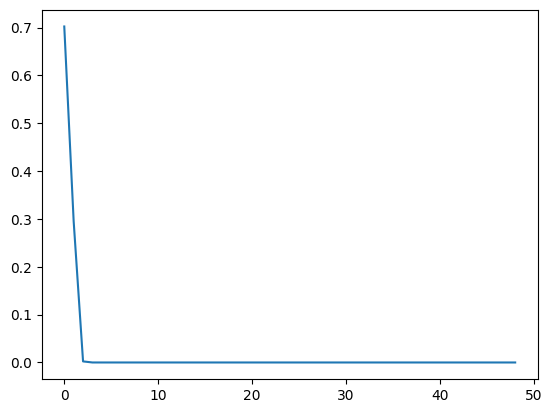

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)), pca.explained_variance_ratio_)

In [ ]:
len(pca.components_),X_train.shape

(49, (1029, 49))

In [ ]:

pca = PCA(random_state=7) # generate all possible components
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

X_train_pca.shape,X_test_pca.shape

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


((1029, 49), (441, 49))

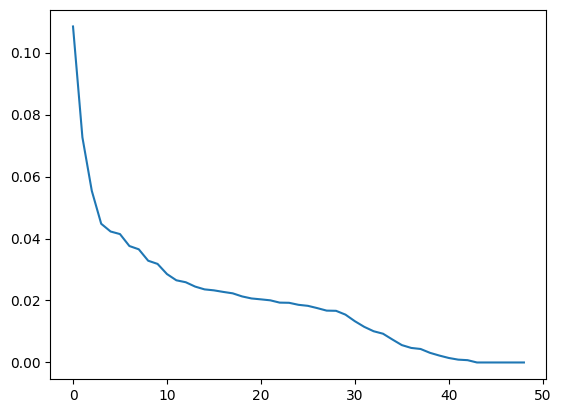

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)), pca.explained_variance_ratio_)

In [ ]:
pca.explained_variance_ratio_

array([1.08423844e-01, 7.26508683e-02, 5.53801487e-02, 4.47591141e-02,
       4.22618996e-02, 4.14326857e-02, 3.75805218e-02, 3.65224376e-02,
       3.28370936e-02, 3.18078455e-02, 2.85347516e-02, 2.65198316e-02,
       2.58922827e-02, 2.44863065e-02, 2.35889060e-02, 2.32749099e-02,
       2.27668322e-02, 2.23118664e-02, 2.13132298e-02, 2.06581513e-02,
       2.03699587e-02, 2.00564644e-02, 1.93148529e-02, 1.92585661e-02,
       1.86080882e-02, 1.82794829e-02, 1.75433901e-02, 1.67348832e-02,
       1.66704326e-02, 1.54416424e-02, 1.33230121e-02, 1.14993815e-02,
       1.00801405e-02, 9.28311261e-03, 7.41362987e-03, 5.61221961e-03,
       4.69592371e-03, 4.35467626e-03, 3.11272351e-03, 2.22887748e-03,
       1.45351501e-03, 9.17395201e-04, 7.44104344e-04, 5.51603757e-18,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

In [ ]:

## pass the training data with Standard Scaler -- imputed
pca = PCA(random_state=7) # generate all possible components
X_train_pca = pca.fit_transform(X_train_sc_io)
X_test_pca = pca.transform(X_test)

X_train_pca.shape,X_test_pca.shape

((1029, 49), (441, 49))

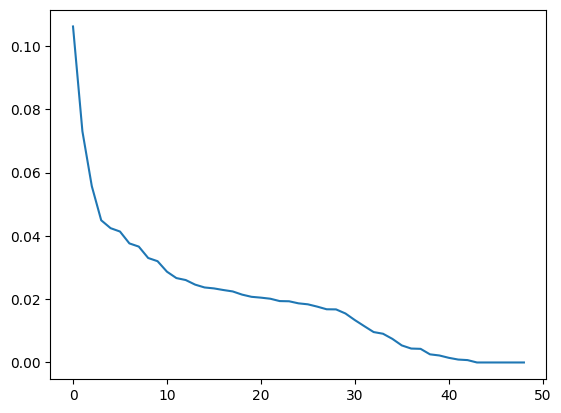

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)), pca.explained_variance_ratio_)

In [ ]:
pca.explained_variance_ratio_

array([0.1061923 , 0.07306001, 0.05572069, 0.04494519, 0.04244751,
       0.0413836 , 0.03763459, 0.03662156, 0.0330237 , 0.03200981,
       0.028693  , 0.02667978, 0.0260511 , 0.02460346, 0.02370964,
       0.02341147, 0.02290231, 0.02245184, 0.02144434, 0.0207527 ,
       0.02048948, 0.02014952, 0.01940498, 0.01934381, 0.01869146,
       0.01838089, 0.01764996, 0.0168149 , 0.01677584, 0.01548658,
       0.01340121, 0.01149137, 0.00961431, 0.00908239, 0.00745321,
       0.00538941, 0.00440138, 0.00430935, 0.00257112, 0.00221221,
       0.00147529, 0.00092383, 0.0007489 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [ ]:


pca = PCA(n_components=0.9,random_state=7) # generate all possible components
X_train_pca = pca.fit_transform(X_train_sc_io)
X_test_pca = pca.transform(X_test)

X_train_pca.shape,X_test_pca.shape  # 20 columns reduced

((1029, 29), (441, 29))